# Falcon Reservoir — Resilient Release Scheduling (QUBO + QAOA / SA)

Benchmark for the Falcon Challenge: encode the weekly release-adjustment problem
as a **QUBO** and optimize the **Storage Resilience Score (SRS)** with a quantum
method (**QAOA**) plus a scalable quantum-inspired solver (**simulated annealing**),
on **real IBWC Falcon data**.

**Structure**
1. **Setup** — install, Aer sampler, QUBO helpers, QAOA solver.
2. **Benchmark suite** — general-L QUBO encoding, official SRS scoring, constraints,
   classical baselines, and the SA solver.
3. **Real data** — loaded via the team's `preparar_ventana_semanal`; a QAOA
   validation on a small slice; and a **scaling benchmark** across the Section-6
   instances (small T=12/L=3 + official medium T=26/L=5) with ΔSRS + plots.

**Official parameters:** L=5 levels `{-2Δu,-Δu,0,Δu,2Δu}`, `Δu = 0.25·median(R_obs)`,
`umax = 2Δu`, `w1 = 1/((T+1)Smin²)`, `w2 = 0.1/(T·umax²)`, `w3 = 0.1/((T-1)(2umax)²)`,
`Smin = 0.25·Smax`, `η = 0.10`.

## 1. Install dependencies

In [13]:
# Match the versions your PLATFORM already expects. Do NOT blindly `-U` to the
# latest -- that pulled qiskit 2.4.2, which conflicts with the preinstalled
# pennylane-qiskit 0.45.0 (needs qiskit>=2.0,<=2.3 and qiskit-aer~=0.17.2).
#
# GPU NOTE: there is NO qiskit-aer-gpu wheel for the 0.17.x / qiskit-2.x line
# (qiskit-aer-gpu on PyPI stops at 0.15.1, which needs the old qiskit 1.x).
# So we install the standard CPU build of qiskit-aer 0.17.2. For 18 qubits
# this is plenty fast -- GPU only matters for much larger circuits.
#
# Install with the KERNEL's own interpreter (sys.executable) so it lands in the
# environment the kernel actually uses.

import sys
print("Kernel interpreter:", sys.executable)

# Pinned, mutually-compatible stack (also satisfies pennylane-qiskit 0.45.0):
!{sys.executable} -m pip install -q \
    "qiskit>=2.0,<=2.3.0" \
    "qiskit-aer~=0.17.2" \
    "qiskit-algorithms" "qiskit-optimization" scipy numpy matplotlib

# >>> After this cell finishes, RESTART THE KERNEL, then run from the top. <<<
# Python caches the previously-imported qiskit/qiskit_aer, so a restart is
# required for the pinned versions to take effect.
#
# Sanity check (run in a fresh cell AFTER restarting):
#     import qiskit, qiskit_aer
#     print(qiskit.__version__, qiskit_aer.__version__)   # expect 2.3.x and 0.17.x
#
# §2 will report "Aer SamplerV2 (CPU)". The GPU probe there will simply fail
# the smoke test and fall through to CPU -- that is expected on a CPU aer build.
#
# NOTE: even if Aer still refuses to load, the QAOA solver below has a fast,
# Aer-free NumPy statevector path, so the notebook will still complete.

Kernel interpreter: /opt/qcentroid-venv/bin/python


## 2. Imports and GPU-capable sampler setup

In [14]:
import itertools
import warnings
import subprocess
import shutil
import time
import inspect

import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import SparseEfficiencyWarning
warnings.filterwarnings("ignore", category=SparseEfficiencyWarning)

from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA


def print_gpu_info():
    if shutil.which("nvidia-smi") is None:
        print("nvidia-smi not found. GPU may not be attached.")
        return False
    try:
        out = subprocess.check_output(
            [
                "nvidia-smi",
                "--query-gpu=name,memory.total,memory.free",
                "--format=csv,noheader",
            ],
            text=True,
        )
        print("Detected GPU:")
        print(out)
        return True
    except Exception as exc:
        print("Could not query GPU:", repr(exc))
        return False

gpu_visible = print_gpu_info()

# ------------------------------------------------------------
# Sampler setup
# ------------------------------------------------------------
# We use Aer's *native* SamplerV2 primitive. It transpiles the QAOA ansatz
# to Aer-supported gates internally, so we do NOT need a manual preset pass
# manager and we never hit "unknown instruction: QAOA".
#
# Preference order:
#   1. Aer SamplerV2 on GPU
#   2. Aer SamplerV2 on CPU
#   3. Reference StatevectorSampler (pure Python, slowest, last resort)
#
# Each candidate is smoke-tested with a tiny circuit so a broken backend
# fails HERE (fast, visible) instead of hanging deep inside QAOA.
# ------------------------------------------------------------

DEFAULT_SHOTS = 256

sampler = None
sampler_mode = None
backend_for_test = None  # kept for the optional test cell below


def _make_aer_sampler(device):
    from qiskit_aer.primitives import SamplerV2 as AerSamplerV2
    return AerSamplerV2(
        default_shots=DEFAULT_SHOTS,
        seed=123,
        options={"backend_options": {"method": "statevector", "device": device}},
    )


def _smoke_test(smp):
    from qiskit import QuantumCircuit
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0, 1)
    qc.measure_all()
    smp.run([qc], shots=16).result()


for device in ("GPU", "CPU"):
    try:
        candidate = _make_aer_sampler(device)
        _smoke_test(candidate)
        sampler = candidate
        sampler_mode = f"Aer SamplerV2 ({device})"
        break
    except Exception as exc:
        print(f"Aer SamplerV2 ({device}) unavailable:", repr(exc))

if sampler is None:
    print("Falling back to the pure-Python reference sampler (slow for 18 qubits).")
    from qiskit.primitives import StatevectorSampler
    sampler = StatevectorSampler(default_shots=DEFAULT_SHOTS, seed=123)
    sampler_mode = "StatevectorSampler (reference, pure Python)"

print("Using sampler:", sampler_mode)

# Show QAOA signature (informational).
print("QAOA signature:")
print(inspect.signature(QAOA))

Detected GPU:
Tesla T4, 15360 MiB, 14701 MiB

Aer SamplerV2 (GPU) unavailable: RuntimeError('Simulation device "GPU" is not supported on this system')
Using sampler: Aer SamplerV2 (CPU)
QAOA signature:
(sampler: 'BaseSamplerV2', optimizer: 'Optimizer | Minimizer', *, reps: 'int' = 1, initial_state: 'QuantumCircuit | None' = None, mixer: 'QuantumCircuit | BaseOperator' = None, initial_point: 'np.ndarray | None' = None, aggregation: 'float | Callable[[list[float]], float] | None' = None, callback: 'Callable[[int, np.ndarray, float, dict[str, Any]], None] | None' = None, transpiler: 'Transpiler | None' = None, transpiler_options: 'dict[str, Any] | None' = None) -> 'None'


## 3. QUBO helper functions

In [15]:
def add_quadratic(Q, i, j, value):
    """
    Add value * x_i * x_j using upper-triangular QUBO convention.
    """
    if i == j:
        Q[i, i] += value
    else:
        a, b = min(i, j), max(i, j)
        Q[a, b] += value


def add_squared_expression(Q, constant, coeffs, penalty):
    """
    Add:

        penalty * (constant + sum_i coeffs[i] x_i)^2

    to the QUBO matrix Q.

    Since x_i is binary, x_i^2 = x_i.

    Diagonal:
        penalty * (r_i^2 + 2 constant r_i)

    Off-diagonal:
        penalty * 2 r_i r_j
    """
    items = list(coeffs.items())

    for i, ri in items:
        Q[i, i] += penalty * (ri**2 + 2.0 * constant * ri)

    for p in range(len(items)):
        i, ri = items[p]
        for q in range(p + 1, len(items)):
            j, rj = items[q]
            add_quadratic(Q, i, j, penalty * 2.0 * ri * rj)


def qubo_energy(x, Q):
    return float(x @ Q @ x)

## 4. Convert the QUBO to a Qiskit `QuadraticProgram`

In [16]:
def qubo_matrix_to_quadratic_program(Q):
    """
    Convert an upper-triangular QUBO matrix to a Qiskit QuadraticProgram.
    """
    from qiskit_optimization import QuadraticProgram

    n = Q.shape[0]
    qp = QuadraticProgram("complex_gpu_reservoir_qubo")

    for i in range(n):
        qp.binary_var(name=f"x_{i}")

    linear = {}
    quadratic = {}

    for i in range(n):
        if abs(Q[i, i]) > 1e-12:
            linear[f"x_{i}"] = Q[i, i]

    for i in range(n):
        for j in range(i + 1, n):
            if abs(Q[i, j]) > 1e-12:
                quadratic[(f"x_{i}", f"x_{j}")] = Q[i, j]

    qp.minimize(linear=linear, quadratic=quadratic)
    return qp

## 5. Why the QAOA ansatz must be transpiled for Aer

The Aer backend can only execute instructions it knows how to simulate. In some Qiskit versions, the QAOA ansatz reaches the backend as a high-level instruction named `QAOA`.

If that high-level instruction is not decomposed first, Aer raises:

```text
AerError: 'unknown instruction: QAOA'
```

To avoid this, the QAOA solver below passes a preset pass manager into the `QAOA` constructor. That pass manager transpiles/decomposes the circuit before sampling.

## 6. QAOA solver

In [17]:
from types import SimpleNamespace


def _solve_qaoa_qiskit(Q, reps, maxiter, verbose):
    """
    QAOA via qiskit_algorithms.QAOA + the global Aer `sampler`.

    IMPORTANT: in this qiskit version the QAOA ansatz reaches Aer as a
    high-level 'QAOA' instruction that Aer cannot execute, raising
    'unknown instruction: QAOA'. We therefore pass a preset pass manager via
    QAOA(transpiler=...) so the ansatz is decomposed to basis gates BEFORE it
    reaches the sampler.
    """
    from qiskit_algorithms import QAOA
    from qiskit_algorithms.optimizers import COBYLA
    from qiskit_optimization.algorithms import MinimumEigenOptimizer
    from qiskit_aer import AerSimulator
    from qiskit.transpiler import generate_preset_pass_manager

    pass_manager = generate_preset_pass_manager(
        optimization_level=1,
        backend=AerSimulator(),
        seed_transpiler=123,
    )

    qp = qubo_matrix_to_quadratic_program(Q)
    eval_count = {"n": 0}
    t0 = time.time()

    def _callback(eval_index, params, mean, metadata):
        eval_count["n"] += 1
        if verbose:
            print(f"[QAOA/qiskit] eval {eval_count['n']:>3}  energy = {mean:.6f}  "
                  f"elapsed = {time.time() - t0:6.1f}s", flush=True)

    qaoa = QAOA(
        sampler=sampler,
        optimizer=COBYLA(maxiter=maxiter),
        reps=reps,
        initial_point=np.zeros(2 * reps),
        callback=_callback,
        transpiler=pass_manager,   # <-- decomposes the ansatz for Aer
    )
    result = MinimumEigenOptimizer(qaoa).solve(qp)
    if verbose:
        print(f"[QAOA/qiskit] done: {eval_count['n']} evals in {time.time() - t0:.1f}s")
    return result, qp


def _solve_qaoa_statevector(Q, reps, maxiter, n_restarts=4, seed=123, shots=4096,
                            verbose=True):
    """
    Exact statevector QAOA in pure NumPy. No qiskit-aer, no reference-sampler
    overhead. Fast and reliable for up to ~22-24 qubits.

    The QUBO cost C(x) = x^T Q x is DIAGONAL in the computational basis, so the
    cost layer exp(-i*gamma*C) is just an elementwise phase, and the mixer
    exp(-i*beta*sum_j X_j) is a product of single-qubit X-rotations. We optimise
    (gamma, beta) with COBYLA on the exact expectation <C>, then sample the final
    state and return the lowest-cost bitstring (standard QAOA readout).
    """
    from scipy.optimize import minimize

    n = Q.shape[0]
    dim = 1 << n
    if n > 24:
        raise ValueError(f"{n} qubits too large for dense statevector simulation.")

    # Precompute C(x) for every basis state (bit i of index -> variable x_i).
    idx = np.arange(dim, dtype=np.uint64)
    bits = ((idx[:, None] >> np.arange(n, dtype=np.uint64)) & 1).astype(np.float64)
    C = np.zeros(dim)
    for i in range(n):
        if Q[i, i]:
            C += Q[i, i] * bits[:, i]
        for j in range(i + 1, n):
            if Q[i, j]:
                C += Q[i, j] * bits[:, i] * bits[:, j]

    plus = np.full(dim, 1.0 / np.sqrt(dim), dtype=complex)

    def mixer(state, beta):
        c = np.cos(beta)
        s = -1j * np.sin(beta)
        st = state.reshape([2] * n)
        for ax in range(n):
            st = np.moveaxis(st, ax, 0)
            a = st[0].copy()
            b = st[1].copy()
            st[0] = c * a + s * b
            st[1] = s * a + c * b
            st = np.moveaxis(st, 0, ax)
        return st.reshape(-1)

    def run_state(params):
        gammas, betas = params[:reps], params[reps:]
        state = plus.copy()
        for k in range(reps):
            state = state * np.exp(-1j * gammas[k] * C)
            state = mixer(state, betas[k])
        return state

    def objective(params):
        probs = np.abs(run_state(params)) ** 2
        return float(probs @ C)

    rng = np.random.default_rng(seed)
    t0 = time.time()
    best = None
    for r in range(n_restarts):
        x0 = np.full(2 * reps, 0.1) if r == 0 else rng.uniform(0, np.pi, size=2 * reps)
        res = minimize(objective, x0, method="COBYLA", options={"maxiter": maxiter})
        if best is None or res.fun < best.fun:
            best = res
        if verbose:
            print(f"[QAOA/statevector] restart {r + 1}/{n_restarts}  "
                  f"expectation = {res.fun:.6f}  best = {best.fun:.6f}  "
                  f"elapsed = {time.time() - t0:5.1f}s", flush=True)

    probs = np.abs(run_state(best.x)) ** 2
    probs = probs / probs.sum()
    sample_idx = rng.choice(dim, size=shots, p=probs)
    best_index = int(sample_idx[np.argmin(C[sample_idx])])
    x_bits = np.array([(best_index >> i) & 1 for i in range(n)], dtype=float)

    if verbose:
        print(f"[QAOA/statevector] done in {time.time() - t0:.1f}s  "
              f"best sampled energy = {C[best_index]:.6f}")

    result = SimpleNamespace(x=x_bits, fval=float(C[best_index]),
                             optimal_parameters=best.x)
    return result, qubo_matrix_to_quadratic_program(Q)


def solve_with_qaoa(Q, reps=1, maxiter=50, method="auto", verbose=True):
    """
    Solve the QUBO with QAOA.

    method="auto" (default): use the qiskit + Aer sampler path if an Aer
    backend actually loaded; if that path raises (e.g. an Aer decomposition
    error), automatically fall back to the fast pure-NumPy statevector QAOA so
    the notebook still completes.

    Force a path with method="qiskit" or method="statevector".
    """
    aer_active = str(globals().get("sampler_mode", "")).startswith("Aer")

    if method == "qiskit" or (method == "auto" and aer_active):
        if verbose:
            print(f"Solving with qiskit QAOA on: {sampler_mode}")
        try:
            return _solve_qaoa_qiskit(Q, reps, maxiter, verbose)
        except Exception as exc:
            if method == "qiskit":
                raise
            print(f"qiskit QAOA path failed ({type(exc).__name__}: {exc}).")
            print("Falling back to the pure-NumPy statevector QAOA.")

    if verbose:
        reason = "forced" if method == "statevector" else "Aer unavailable / fallback"
        print(f"Solving with pure-NumPy statevector QAOA ({reason}).")
    return _solve_qaoa_statevector(Q, reps, maxiter, verbose=verbose)

# Benchmark suite (encoding, scoring, solvers)

Everything below is data-agnostic and scales to any T, L:

* **QUBO encoding** with L one-hot levels per week and the official SRS weights.
* **Official SRS** scoring (true `max(0,·)` critical term) + all feasibility
  constraints (Eqs. 5-8).
* **Baselines:** historical replay (`u=0`) and the threshold rule (Eq. 18).
* **QAOA** (exact statevector) for small validation slices (≤ ~22 qubits).
* **Simulated annealing** on the QUBO — the scalable quantum-inspired solver used
  for the official 130-qubit instance.

The real Falcon data + official benchmark run are in the next section.

In [18]:
# ============================================================
# B.1  Benchmark core: data, general-L encoding, official SRS, constraints
# ============================================================
import numpy as np
import time
import itertools

ETA = 0.10   # cumulative release-balance factor (Eq. 14)


def make_levels(L):
    """Symmetric integer amplitudes: L=3 -> [-1,0,1], L=5 -> [-2,-1,0,1,2]."""
    assert L % 2 == 1, "Use an odd L so level 0 is included."
    half = (L - 1) // 2
    return list(range(-half, half + 1))


def storage_traj(u, inst):
    """S(t+1) = S(t) + dS_obs(t) - u(t)  (Eq. 3). Returns S[0..T]."""
    S = np.empty(inst["T"] + 1)
    S[0] = inst["S0"]
    for t in range(inst["T"]):
        S[t + 1] = S[t] + inst["dS_obs"][t] - u[t]
    return S


def official_weights(inst):
    T, Smin, umax = inst["T"], inst["Smin"], inst["umax"]
    w1 = 1.0 / ((T + 1) * Smin ** 2)                      # Eq. 12, Sscale = Smin
    w2 = 0.1 / (T * umax ** 2)
    w3 = 0.1 / ((T - 1) * (2 * umax) ** 2)
    return w1, w2, w3


def score_srs(u, inst):
    """Official SRS (Eq. 1) with the true max(0, .) critical term."""
    u = np.asarray(u, dtype=float)
    S = storage_traj(u, inst)
    w1, w2, w3 = official_weights(inst)
    Ccrit = float(np.sum(np.maximum(0.0, inst["Smin"] - S) ** 2))
    Cdev = float(np.sum(u ** 2))
    Csmooth = float(np.sum(np.diff(u) ** 2))
    SRS = -(w1 * Ccrit + w2 * Cdev + w3 * Csmooth)
    return {"SRS": SRS, "Ccrit": Ccrit, "Cdev": Cdev, "Csmooth": Csmooth, "S": S}


def is_feasible(u, inst, tol=1e-6):
    """Feasibility constraints Eqs. 5-8."""
    u = np.asarray(u, dtype=float)
    if np.any(inst["R_obs"] + u < -tol):                          # R(t) >= 0   (Eq. 5)
        return False
    if np.any(np.abs(u) > inst["umax"] + tol):                    # |u| <= umax (Eq. 6)
        return False
    S = storage_traj(u, inst)
    if np.any(S < -tol) or np.any(S > inst["Smax"] + tol):        # 0 <= S <= Smax (Eq. 7)
        return False
    if abs(u.sum()) > ETA * inst["R_obs"].sum() + tol:            # cumulative balance (Eq. 8)
        return False
    return True


# ---- Baselines -------------------------------------------------------------

def historical_replay(inst):
    """u_hist(t) = 0  (Eqs. 16-17)."""
    return np.zeros(inst["T"])


def threshold_rule(inst):
    """Classical baseline (Eq. 18): cut release by Delta u while storage < Smin."""
    T, du = inst["T"], inst["delta_u"]
    R_obs, dS_obs, Smin = inst["R_obs"], inst["dS_obs"], inst["Smin"]
    S = np.empty(T + 1); S[0] = inst["S0"]
    u = np.zeros(T)
    for t in range(T):
        urule = -du if S[t] < Smin else 0.0
        if R_obs[t] + urule < 0:
            urule = 0.0
        u[t] = urule
        S[t + 1] = S[t] + dS_obs[t] - urule
    return u


def brute_force(inst, max_schedules=2_000_000):
    """Exhaustive search over feasible schedules (only for small L^T)."""
    T, levels, du = inst["T"], inst["levels"], inst["delta_u"]
    n = len(levels) ** T
    if n > max_schedules:
        raise ValueError(f"{n:,} schedules is too many for brute force.")
    best_u, best_srs = None, -np.inf
    for combo in itertools.product(levels, repeat=T):
        u = du * np.asarray(combo, dtype=float)
        if not is_feasible(u, inst):
            continue
        srs = score_srs(u, inst)["SRS"]
        if srs > best_srs:
            best_srs, best_u = srs, u
    return best_u, best_srs


print("Benchmark core loaded: score_srs, is_feasible,")
print("historical_replay, threshold_rule, brute_force.")

Benchmark core loaded: score_srs, is_feasible,
historical_replay, threshold_rule, brute_force.


In [19]:
# ============================================================
# B.2  Solvers: general-L QUBO (for QAOA) + simulated annealing (quantum-inspired)
# ============================================================
# Reuses add_squared_expression / qubo_energy from the toy section (Part A, §3).


def build_qubo_general(inst, penalty_scale=20.0, bal_scale=2.0):
    """
    QUBO with L one-hot levels per week and OFFICIAL weights. Same structure as
    the toy builder but for arbitrary L. Penalties are auto-scaled to the
    objective magnitude so one-hot is enforced without swamping the objective.
    Ccrit is the QUBO-friendly linearized form (no max), as in Part A.
    """
    T, levels, du = inst["T"], inst["levels"], inst["delta_u"]
    R_obs, dS_obs, S0, Smin = inst["R_obs"], inst["dS_obs"], inst["S0"], inst["Smin"]
    w1, w2, w3 = official_weights(inst)

    index, c = {}, 0
    for t in range(T):
        for a in levels:
            index[(t, a)] = c
            c += 1
    n = c
    Q = np.zeros((n, n))

    # Cdev = sum_t u(t)^2
    for t in range(T):
        add_squared_expression(Q, 0.0, {index[(t, a)]: du * a for a in levels}, w2)

    # Csmooth = sum_{t>=1} (u(t)-u(t-1))^2
    for t in range(1, T):
        coeffs = {}
        for a in levels:
            coeffs[index[(t, a)]] = coeffs.get(index[(t, a)], 0.0) + du * a
            coeffs[index[(t - 1, a)]] = coeffs.get(index[(t - 1, a)], 0.0) - du * a
        add_squared_expression(Q, 0.0, coeffs, w3)

    # Ccrit ~ sum_t (A_t + sum_{tau<t} u(tau))^2 , A_t = Smin - S0 - sum dS
    for t in range(T + 1):
        A_t = Smin - S0 - float(np.sum(dS_obs[:t]))
        coeffs = {}
        for tau in range(t):
            for a in levels:
                i = index[(tau, a)]
                coeffs[i] = coeffs.get(i, 0.0) + du * a
        if coeffs:
            add_squared_expression(Q, A_t, coeffs, w1)

    obj_max = float(np.max(np.abs(Q))) if n else 1.0
    lam_onehot = penalty_scale * max(obj_max, 1e-12)
    lam_bal = bal_scale * max(obj_max, 1e-12) / (T * du) ** 2

    # One-hot: exactly one level per week
    for t in range(T):
        add_squared_expression(Q, -1.0, {index[(t, a)]: 1.0 for a in levels}, lam_onehot)

    # Cumulative-balance soft penalty ~ (sum_t u)^2
    coeffs = {}
    for t in range(T):
        for a in levels:
            coeffs[index[(t, a)]] = du * a
    add_squared_expression(Q, 0.0, coeffs, lam_bal)

    meta = {"T": T, "levels": levels, "index": index, "n": n, "delta_u": du,
            "lam_onehot": lam_onehot, "lam_bal": lam_bal}
    return Q, meta


def decode_general(x, meta):
    """Map a binary vector back to (levels, u), taking argmax per week if not one-hot."""
    T, levels, index, du = meta["T"], meta["levels"], meta["index"], meta["delta_u"]
    sel, u = [], []
    for t in range(T):
        active = [a for a in levels if int(round(x[index[(t, a)]])) == 1]
        chosen = active[0] if len(active) == 1 else max(levels, key=lambda a: x[index[(t, a)]])
        sel.append(chosen)
        u.append(du * chosen)
    return np.array(sel), np.array(u, dtype=float)


def qubo_bruteforce_min(Q, meta):
    """Exact minimum of x^T Q x over all one-hot schedules (small instances only)."""
    T, levels, index, n = meta["T"], meta["levels"], meta["index"], meta["n"]
    best = None
    for combo in itertools.product(levels, repeat=T):
        x = np.zeros(n)
        for t, a in enumerate(combo):
            x[index[(t, a)]] = 1
        e = qubo_energy(x, Q)
        if best is None or e < best[1]:
            best = (combo, e, x)
    return best


def simulated_annealing(inst, seed=0, n_iter=40000, n_restarts=3, verbose=True):
    """
    Quantum-inspired solver: simulated annealing over feasible one-hot schedules,
    minimizing the true objective (-SRS). Single-week level changes; infeasible
    moves (Eqs. 5-8) are rejected, so the returned schedule is always feasible.
    Scales to any T, L (unlike exact QAOA).
    """
    rng = np.random.default_rng(seed)
    T, levels, du = inst["T"], inst["levels"], inst["delta_u"]
    lv = np.asarray(levels, dtype=float)
    L = len(levels)
    zero_idx = levels.index(0)

    def u_of(state):
        return du * lv[state]

    def cost(u):
        if not is_feasible(u, inst):
            return np.inf
        return -score_srs(u, inst)["SRS"]

    best_u_g, best_c_g = None, np.inf
    t0 = time.time()
    for r in range(n_restarts):
        state = np.full(T, zero_idx, dtype=int)   # start at u=0 (feasible)
        cur_c = cost(u_of(state))

        deltas = []
        for _ in range(300):                       # calibrate temperature scale
            s2 = state.copy(); s2[rng.integers(T)] = rng.integers(L)
            c2 = cost(u_of(s2))
            if np.isfinite(c2) and np.isfinite(cur_c):
                deltas.append(abs(c2 - cur_c))
        T0 = max(3.0 * (np.median(deltas) if deltas else 1e-3), 1e-12)
        Tend = T0 / 1000.0

        best_state, best_c = state.copy(), cur_c
        for it in range(n_iter):
            temp = T0 * (Tend / T0) ** (it / max(1, n_iter - 1))
            s2 = state.copy(); s2[rng.integers(T)] = rng.integers(L)
            c2 = cost(u_of(s2))
            if not np.isfinite(c2):
                continue
            if (not np.isfinite(cur_c)) or c2 <= cur_c or rng.random() < np.exp(-(c2 - cur_c) / temp):
                state, cur_c = s2, c2
                if c2 < best_c:
                    best_state, best_c = s2.copy(), c2
        if best_c < best_c_g:
            best_c_g, best_u_g = best_c, u_of(best_state)
        if verbose:
            print(f"[SA] restart {r + 1}/{n_restarts}  best SRS = {-best_c_g:+.6f}  "
                  f"elapsed = {time.time() - t0:5.1f}s", flush=True)

    return best_u_g, -best_c_g


print("Solvers loaded: build_qubo_general, decode_general, qubo_bruteforce_min,")
print("simulated_annealing.")

Solvers loaded: build_qubo_general, decode_general, qubo_bruteforce_min,
simulated_annealing.


In [20]:
# ============================================================
# Reporting helper (per-instance SRS breakdown + solution)
# ============================================================
def report(res):
    inst = res["inst"]
    T, du = inst["T"], inst["delta_u"]
    cap = ETA * inst["R_obs"].sum()
    print(f"\n=== T={res['T']}, L={res['L']}  "
          f"({res['qubits']} qubits,  N = L^T = {float(res['N']):.3e} schedules) ===")
    print(f"  {'policy':<20}{'SRS':>11}   {'Ccrit':>9} {'Cdev':>9} {'Csmooth':>9}  wk<Smin")
    def line(name, u, tag=""):
        m = score_srs(u, inst)
        below = int(np.sum(m["S"] < inst["Smin"]))
        print(f"  {name:<20}{m['SRS']:>+11.6f}   {m['Ccrit']:>9.2e} {m['Cdev']:>9.2e} "
              f"{m['Csmooth']:>9.2e}  {below:>2}/{T+1}{tag}")
    line("historical (u=0)", historical_replay(inst))
    line("threshold rule", threshold_rule(inst), f"   feasible={res['rule_feasible']}")
    line("SA (quantum-insp)", res["u_sa"], f"   feasible={res['sa_feasible']}  {res['sa_time']:.1f}s")
    if "srs_bf" in res:
        print(f"  {'brute-force opt':<20}{res['srs_bf']:>+11.6f}   "
              f"(SA optimality gap = {res['srs_bf'] - res['srs_sa']:.2e}, {res['bf_time']:.1f}s)")
    print(f"  Delta SRS:  SA vs rule = {res['srs_sa']-res['srs_rule']:+.6f}   "
          f"|  SA vs historical = {res['srs_sa']-res['srs_hist']:+.6f}")
    u = res["u_sa"]; lvl = np.round(u / du).astype(int)
    print("  SA solution levels (u/Delta_u):", lvl.tolist())
    print("  SA solution u (TCM/week)      :", np.round(u).astype(int).tolist())
    print(f"  sum(u) = {u.sum():,.0f} TCM  (cap +/-{cap:,.0f});  R(t)>=0 holds: "
          f"{bool(np.all(inst['R_obs'] + u >= -1e-6))}")

print("report() ready.")


report() ready.


# Part C — Real Falcon data via the team loader (`preparar_ventana_semanal`)

Loads the initial values with the **same pipeline as `genetico_v7`** (the DEAP /
Gurobi script), so the QAOA / simulated-annealing results here are directly
comparable to that benchmark.

Requires three files (upload them and point `DATA_DIR` at their folder):

* `R_observ.xlsx` — observed release, column `Valor` (m³/s)
* `Cambio_almacenamiento_historico.csv` — storage change, column `Value (TCM)`
* `DataSetExport-Total Storage.csv` — total storage, column `Value (TCM)`

Conventions copied verbatim from the team script:

* weekly `resample('W-SUN')`: release `.mean()×604.8` (m³/s→TCM/week), ΔS `.sum()`,
  storage `.first()`
* `S_max = 3,387,000 TCM`, `S_min = 0.25·S_max`, window start `2024-01-01`, `L=5`
* storage balance `S(t+1) = S(t) + ΔS_obs(t) − u(t)`, balance cap `|Σu| ≤ 0.10·ΣR_obs`

**What runs here (Section 6 scaling instances):**
* **C.1** loads the medium instance (T=26) + runs the ΔS sign / feasibility checks.
* **QAOA validation** — a small real slice (6 weeks, L=3 → 18 qubits).
* **C.2** runs the **scaling benchmark**: small (T=12, L=3, brute-force-validated)
  and the **official medium** (T=26, L=5). Large (T=52) is one uncomment away.
* **C.3** — scaling summary table + runtime / ΔSRS plots.

> **SRS sign note:** the team script *minimizes* a positive cost
> `w1·Ccrit + w2·Cdev + w3·Csmooth`. This notebook's `score_srs` returns the PDF's
> `SRS = −(that cost)` (higher = better). So `team_cost ≈ −SRS`; ΔSRS is
> sign-independent. (Tiny absolute offset: the team sums `Ccrit` over t=1..T, this
> notebook over t=0..T — a constant that cancels in ΔSRS.)

In [22]:
# ============================================================
# C.1  Load initial values with the team loader (preparar_ventana_semanal)
# ============================================================
import pandas as pd

DATA_DIR = "../dataset"   # folder holding the three files (e.g. "/content" on Colab)
# If read_excel fails:  !pip install -q openpyxl

df_lib    = pd.read_excel(f"{DATA_DIR}/R_observ.xlsx")                       # release, 'Valor', m^3/s
df_cambio = pd.read_csv(f"{DATA_DIR}/Cambio_almacenamiento_historico.csv")   # dS, 'Value (TCM)'
df_total  = pd.read_csv(f"{DATA_DIR}/DataSetExport-Total Storage.csv")       # storage, 'Value (TCM)'


def preparar_ventana_semanal(df_lib, df_cambio, df_total, fecha_inicio_str, semanas):
    """Team loader (genetico_v7): weekly ETL over the planning horizon."""
    dataframes = [df_lib.copy(), df_cambio.copy(), df_total.copy()]
    for i, df in enumerate(dataframes):
        df.columns = df.columns.str.strip()
        if 'Timestamp (UTC-06:00)' in df.columns:
            df.rename(columns={'Timestamp (UTC-06:00)': 'Fecha'}, inplace=True)
        if 'Fecha' in df.columns:
            df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True, errors='coerce')
            df = df.dropna(subset=['Fecha']).set_index('Fecha')
        dataframes[i] = df
    df_lib_p, df_cambio_p, df_total_p = dataframes

    lib_semanal    = df_lib_p['Valor'].resample('W-SUN').mean() * 604.8      # m^3/s -> TCM/week
    cambio_semanal = df_cambio_p['Value (TCM)'].resample('W-SUN').sum()
    total_semanal  = df_total_p['Value (TCM)'].resample('W-SUN').first()

    fecha_inicio = pd.to_datetime(fecha_inicio_str)
    R_obs = lib_semanal.loc[fecha_inicio:].head(semanas).values
    Delta_S_obs = cambio_semanal.loc[fecha_inicio:].head(semanas).values
    S_inicial = total_semanal.loc[:fecha_inicio].iloc[-1]
    return R_obs, Delta_S_obs, S_inicial


# --- team parameters (identical to genetico_v7) ---
T = 26
fecha_inicio_str = '2024-01-01'
S_max = 3387000.0
S_min = 0.25 * S_max

R_obs, Delta_S_obs, S_inicial = preparar_ventana_semanal(
    df_lib, df_cambio, df_total, fecha_inicio_str, T)

mediana_R = float(np.median(R_obs))
delta_u = 0.25 * mediana_R
u_max = 2 * delta_u

# --- wrap into an `inst` for the Part B benchmark (levels = integer amplitudes) ---
inst_real = {
    "T": T, "L": 5, "levels": [-2, -1, 0, 1, 2],
    "R_obs": np.asarray(R_obs, float),
    "dS_obs": np.asarray(Delta_S_obs, float),
    "S0": float(S_inicial),
    "Smin": S_min, "Smax": S_max,
    "delta_u": delta_u, "umax": u_max,
    "window": (fecha_inicio_str, f"+{T} weeks (W-SUN)"),
}

print(f"Loaded via preparar_ventana_semanal   (start {fecha_inicio_str}, T={T}, L=5)")
print(f"  S_max = {S_max:,.0f}   S_min = {S_min:,.0f}   S_inicial = {S_inicial:,.0f} TCM")
print(f"  median R_obs = {mediana_R:,.0f}   delta_u = {delta_u:,.0f}   u_max = {u_max:,.0f} TCM/week")
print(f"  R_obs[:5]       = {np.round(R_obs[:5]).astype(int)}")
print(f"  Delta_S_obs[:5] = {np.round(Delta_S_obs[:5]).astype(int)}")

# --- sanity + dS sign cross-check ------------------------------------------
# u=0 must keep storage within [0, S_max]; and S0 + cumsum(dS) should track the
# ACTUAL weekly Total Storage. If the max error is large, the Change-in-Storage
# file is sign-flipped vs Eq. 3 -> negate Delta_S_obs (see note below).
S_hist = storage_traj(historical_replay(inst_real), inst_real)
_t = df_total.copy(); _t.columns = _t.columns.str.strip()
if 'Timestamp (UTC-06:00)' in _t.columns:
    _t.rename(columns={'Timestamp (UTC-06:00)': 'Fecha'}, inplace=True)
_t['Fecha'] = pd.to_datetime(_t['Fecha'], dayfirst=True, errors='coerce')
_t = _t.dropna(subset=['Fecha']).set_index('Fecha')
_actual = _t['Value (TCM)'].resample('W-SUN').first().loc[pd.to_datetime(fecha_inicio_str):].head(T + 1).values
_model = S_inicial + np.concatenate([[0.0], np.cumsum(Delta_S_obs)])
_n = min(len(_actual), len(_model))
_err = float(np.max(np.abs(_model[:_n] - _actual[:_n]))) if _n else float("nan")

print(f"  historical storage: {S_hist.min():,.0f} .. {S_hist.max():,.0f} TCM   "
      f"| u=0 feasible: {is_feasible(historical_replay(inst_real), inst_real)}"
      f"  | below Smin all weeks: {bool(np.all(S_hist < S_min))}")
print(f"  dS sign check: max|S0+cumsum(dS) - actual storage| = {_err:,.0f} TCM  "
      f"-> {'OK' if _err < 0.05 * S_max else 'LARGE: Delta_S_obs looks sign-flipped; use  inst_real[\"dS_obs\"] *= -1'}")

/tmp/ipykernel_7554/3958472627.py:22: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True, errors='coerce')


Loaded via preparar_ventana_semanal   (start 2024-01-01, T=26, L=5)
  S_max = 3,387,000   S_min = 846,750   S_inicial = 581,232 TCM
  median R_obs = 14,471   delta_u = 3,618   u_max = 7,235 TCM/week
  R_obs[:5]       = [13794 15638 12462 10573 14769]
  Delta_S_obs[:5] = [  7892   1392   -464 -20078 -45848]
  historical storage: 308,456 .. 866,488 TCM   | u=0 feasible: True  | below Smin all weeks: False
  dS sign check: max|S0+cumsum(dS) - actual storage| = 575,387 TCM  -> LARGE: Delta_S_obs looks sign-flipped; use  inst_real["dS_obs"] *= -1


In [23]:
# ============================================================
# QAOA validation on a REDUCED slice of the REAL data (<=22 qubits)
# ============================================================
# The full instance is 130 qubits (statevector-infeasible). We validate the QUBO
# encoding + QAOA on the first 6 weeks with L=3 (18 qubits): QAOA should reach the
# exact QUBO minimum found by brute force. Uses inst_real from the loader above.
Tv, Lv = 6, 3
val = dict(inst_real)
val.update(T=Tv, L=Lv, levels=[-1, 0, 1],
           R_obs=inst_real["R_obs"][:Tv], dS_obs=inst_real["dS_obs"][:Tv])
val["delta_u"] = 0.25 * float(np.median(val["R_obs"]))
val["umax"] = max(abs(a) for a in val["levels"]) * val["delta_u"]

Qv, meta_v = build_qubo_general(val)
print(f"Validation slice: first {Tv} weeks, L={Lv} -> {meta_v['n']} qubits")

combo, e_min, x_min = qubo_bruteforce_min(Qv, meta_v)
qres, _ = solve_with_qaoa(Qv, reps=2, maxiter=80, method="statevector", verbose=True)
print(f"\nBrute-force QUBO minimum : {e_min:.6f}")
print(f"QAOA QUBO energy         : {qres.fval:.6f}")
print(f"QAOA reached optimum     : {abs(qres.fval - e_min) < 1e-6}")

_, u_qaoa = decode_general(qres.x, meta_v)
print(f"QAOA schedule feasible   : {is_feasible(u_qaoa, val)}  |  "
      f"SRS = {score_srs(u_qaoa, val)['SRS']:+.6f}")


Validation slice: first 6 weeks, L=3 -> 18 qubits
Solving with pure-NumPy statevector QAOA (forced).
[QAOA/statevector] restart 1/4  expectation = -4.534097  best = -4.534097  elapsed =   9.6s
[QAOA/statevector] restart 2/4  expectation = -5.853611  best = -5.853611  elapsed =  19.2s
[QAOA/statevector] restart 3/4  expectation = -4.312461  best = -5.853611  elapsed =  28.7s
[QAOA/statevector] restart 4/4  expectation = -5.977387  best = -5.977387  elapsed =  37.2s
[QAOA/statevector] done in 37.3s  best sampled energy = -6.402609

Brute-force QUBO minimum : -6.402609
QAOA QUBO energy         : -6.402609
QAOA reached optimum     : True
QAOA schedule feasible   : True  |  SRS = -0.117375


In [24]:
# ============================================================
# C.2  Scaling benchmark on REAL data (small + official medium)
# ============================================================
# PDF Section 6 scaling instances. qubits = T*L.
#   small  : T=12, L=3  (36 qubits, 3^12 schedules -> brute-force validatable)
#   medium : T=26, L=5  (130 qubits)  <- OFFICIAL headline comparison
#   large  : T=52, L=5  (260 qubits)  -- optional, uncomment (slower)

def build_real_inst(T, L, fecha_inicio=fecha_inicio_str):
    """Build a benchmark `inst` from the real data via preparar_ventana_semanal."""
    R, dS, S0 = preparar_ventana_semanal(df_lib, df_cambio, df_total, fecha_inicio, T)
    R, dS = np.asarray(R, float), np.asarray(dS, float)
    levels = list(range(-(L - 1) // 2, (L - 1) // 2 + 1))
    du = 0.25 * float(np.median(R))
    umax = max(abs(a) for a in levels) * du
    return {"T": T, "L": L, "levels": levels, "R_obs": R, "dS_obs": dS,
            "S0": float(S0), "Smin": S_min, "Smax": S_max,
            "delta_u": du, "umax": umax, "window": (fecha_inicio, f"+{T}w")}


def run_real(T, L, do_bf=False, n_iter=60000):
    inst = build_real_inst(T, L)
    u_rule = threshold_rule(inst)
    res = {"T": T, "L": L, "qubits": T * L, "N": L ** T, "inst": inst,
           "srs_hist": score_srs(historical_replay(inst), inst)["SRS"],
           "srs_rule": score_srs(u_rule, inst)["SRS"],
           "rule_feasible": is_feasible(u_rule, inst)}
    print(f"\n>>> T={T}, L={L}  ({T*L} qubits)  --  simulated annealing...")
    t0 = time.time()
    u_sa, srs_sa = simulated_annealing(inst, n_iter=n_iter, verbose=False)
    res.update(srs_sa=srs_sa, sa_feasible=is_feasible(u_sa, inst),
               sa_time=time.time() - t0, u_sa=u_sa)
    if do_bf:
        print(f"    brute-forcing {L**T:,} schedules to validate SA (may take ~1 min)...")
        t0 = time.time()
        _, sbf = brute_force(inst)
        res.update(srs_bf=sbf, bf_time=time.time() - t0)
    report(res)
    return res


results = []
results.append(run_real(12, 3, do_bf=True))       # small  (validation)
results.append(run_real(26, 5))                    # medium (OFFICIAL headline)
# results.append(run_real(52, 5, n_iter=100000))   # large  (optional; slower)

# report() above prints each instance's full SRS breakdown + solution.
print("\n[official T=26, L=5]  team-convention cost (= -SRS) =",
      round(-results[1]["srs_sa"], 6))


/tmp/ipykernel_7554/3958472627.py:22: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True, errors='coerce')



>>> T=12, L=3  (36 qubits)  --  simulated annealing...
    brute-forcing 531,441 schedules to validate SA (may take ~1 min)...

=== T=12, L=3  (36 qubits,  N = L^T = 5.314e+05 schedules) ===
  policy                      SRS       Ccrit      Cdev   Csmooth  wk<Smin
  historical (u=0)      -0.221356    2.06e+12  0.00e+00  0.00e+00  13/13
  threshold rule        -0.298432    1.85e+12  1.18e+08  0.00e+00  13/13   feasible=False
  SA (quantum-insp)     -0.221356    2.06e+12  0.00e+00  0.00e+00  13/13   feasible=True  13.3s
  brute-force opt       -0.221356   (SA optimality gap = 0.00e+00, 29.9s)
  Delta SRS:  SA vs rule = +0.077075   |  SA vs historical = +0.000000
  SA solution levels (u/Delta_u): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  SA solution u (TCM/week)      : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  sum(u) = 0 TCM  (cap +/-14,805);  R(t)>=0 holds: True


/tmp/ipykernel_7554/3958472627.py:22: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True, errors='coerce')



>>> T=26, L=5  (130 qubits)  --  simulated annealing...

=== T=26, L=5  (130 qubits,  N = L^T = 1.490e+18 schedules) ===
  policy                      SRS       Ccrit      Cdev   Csmooth  wk<Smin
  historical (u=0)      -0.156312    3.03e+12  0.00e+00  0.00e+00  23/27
  threshold rule        -0.149991    2.55e+12  2.49e+08  1.31e+07  20/27   feasible=True
  SA (quantum-insp)     -0.145371    2.60e+12  1.44e+08  1.31e+07  22/27   feasible=True  15.7s
  Delta SRS:  SA vs rule = +0.004620   |  SA vs historical = +0.010941
  SA solution levels (u/Delta_u): [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  SA solution u (TCM/week)      : [-3618, -3618, -3618, -3618, -3618, -3618, -3618, -3618, -3618, -3618, -3618, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  sum(u) = -39,795 TCM  (cap +/-82,213);  R(t)>=0 holds: True

[official T=26, L=5]  team-convention cost (= -SRS) = 0.145371


instance      qubits      N = L^T  SA t(s)   dSRS/rule   dSRS/hist
------------------------------------------------------------------
T=12,L=3          36     5.31e+05     13.3    0.077075    0.000000
T=26,L=5         130     1.49e+18     15.7    0.004620    0.010941


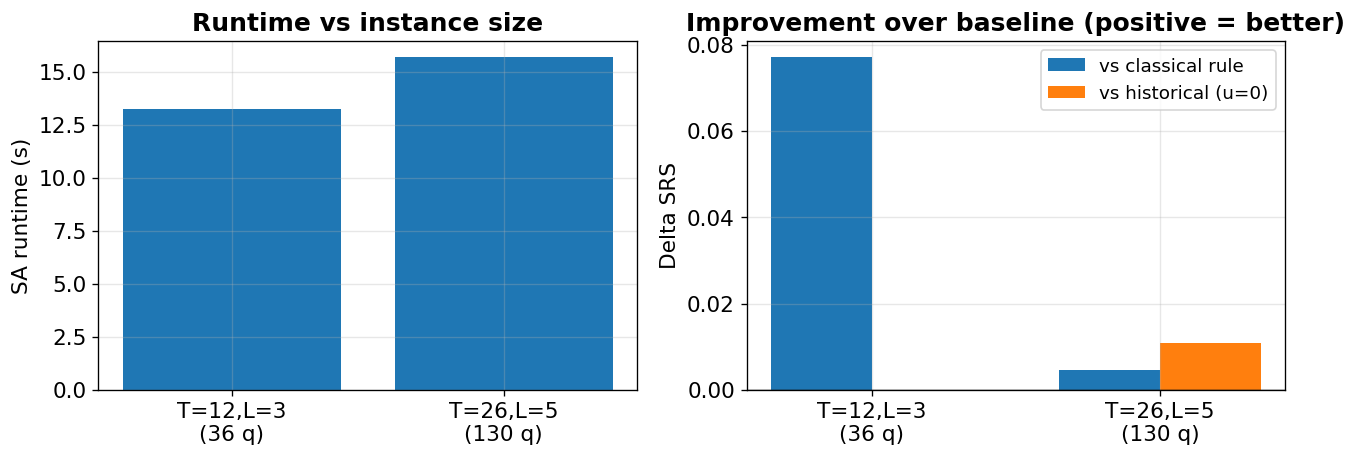

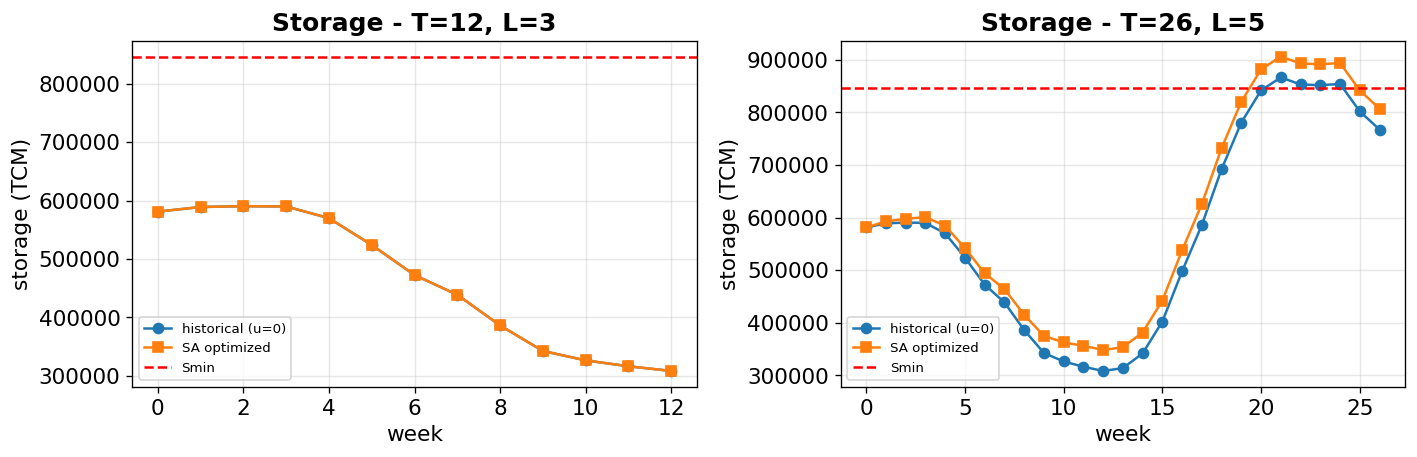

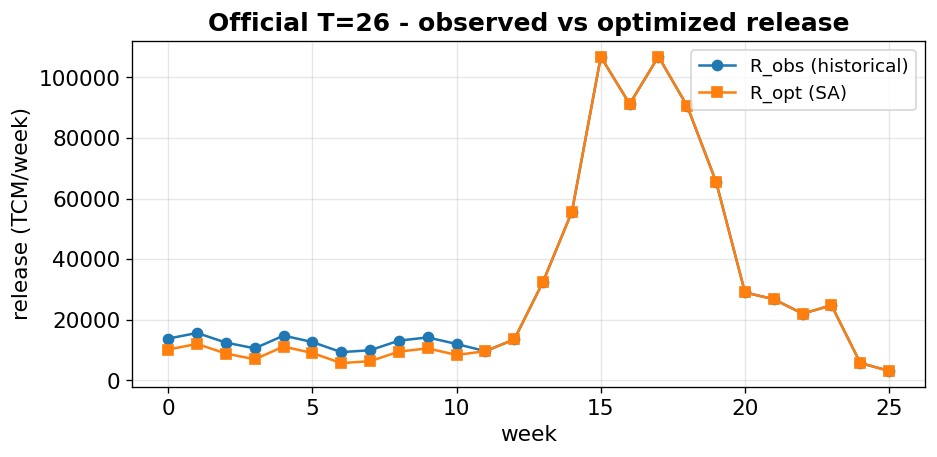

In [25]:
# ============================================================
# C.3  Scaling summary + plots (PDF Section 5 reporting)
# ============================================================
print(f"{'instance':<12}{'qubits':>8}{'N = L^T':>13}{'SA t(s)':>9}"
      f"{'dSRS/rule':>12}{'dSRS/hist':>12}")
print("-" * 66)
for r in results:
    print(f"{'T='+str(r['T'])+',L='+str(r['L']):<12}{r['qubits']:>8}"
          f"{float(r['N']):>13.2e}{r['sa_time']:>9.1f}"
          f"{r['srs_sa']-r['srs_rule']:>12.6f}{r['srs_sa']-r['srs_hist']:>12.6f}")

labels = [f"T={r['T']},L={r['L']}\n({r['qubits']} q)" for r in results]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(labels, [r["sa_time"] for r in results], color="tab:blue")
ax[0].set_ylabel("SA runtime (s)"); ax[0].set_title("Runtime vs instance size")
x = np.arange(len(results)); w = 0.35
ax[1].bar(x - w / 2, [r["srs_sa"] - r["srs_rule"] for r in results], w, label="vs classical rule")
ax[1].bar(x + w / 2, [r["srs_sa"] - r["srs_hist"] for r in results], w, label="vs historical (u=0)")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_xticks(x); ax[1].set_xticklabels(labels)
ax[1].set_ylabel("Delta SRS"); ax[1].set_title("Improvement over baseline (positive = better)")
ax[1].legend(); plt.tight_layout(); plt.show()

# storage trajectories: historical (u=0) vs SA-optimized, with Smin
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 4), squeeze=False)
for a, r in zip(axes[0], results):
    inst = r["inst"]; wk = np.arange(inst["T"] + 1)
    a.plot(wk, storage_traj(historical_replay(inst), inst), "o-", label="historical (u=0)")
    a.plot(wk, storage_traj(r["u_sa"], inst), "s-", label="SA optimized")
    a.axhline(inst["Smin"], ls="--", color="r", label="Smin")
    a.set_title(f"Storage - T={r['T']}, L={r['L']}")
    a.set_xlabel("week"); a.set_ylabel("storage (TCM)"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

# observed vs optimized release for the official (medium) instance
med = results[1]; inst = med["inst"]; wk = np.arange(inst["T"])
plt.figure(figsize=(8, 4))
plt.plot(wk, inst["R_obs"], "o-", label="R_obs (historical)")
plt.plot(wk, inst["R_obs"] + med["u_sa"], "s-", label="R_opt (SA)")
plt.title("Official T=26 - observed vs optimized release")
plt.xlabel("week"); plt.ylabel("release (TCM/week)"); plt.legend()
plt.tight_layout(); plt.show()


# Part D — Presentation figures

Slide-ready charts saved to `figures/*.png` (dpi 200). Run after C.2/C.3 so
`results` (small = `results[0]`, official medium = `results[1]`) and the QAOA
validation variables (`qres`, `e_min`, `meta_v`) exist.

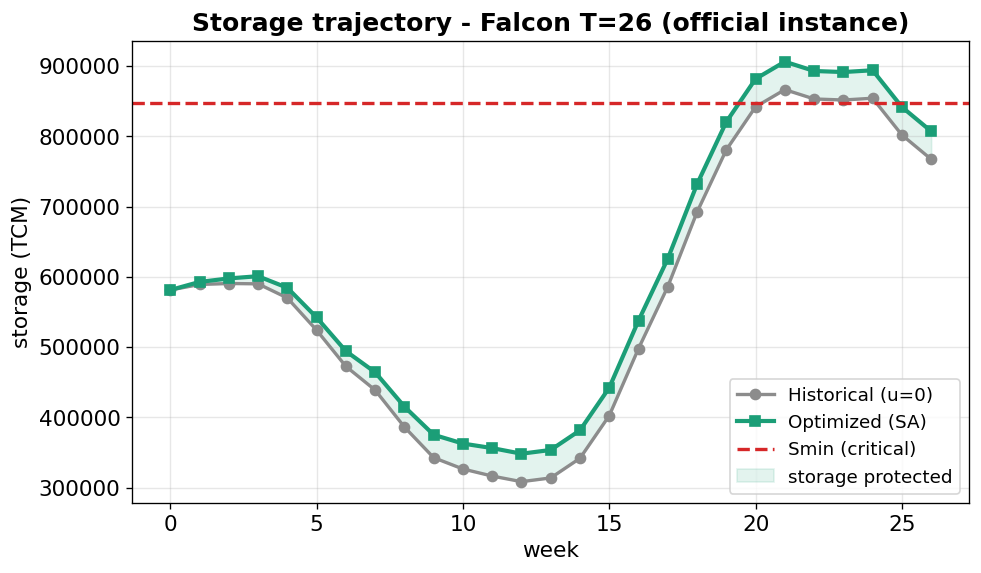

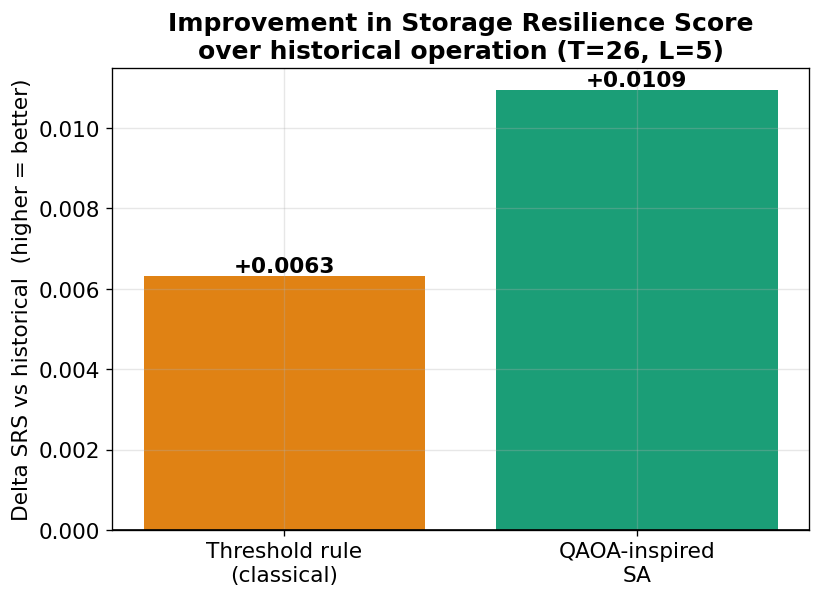

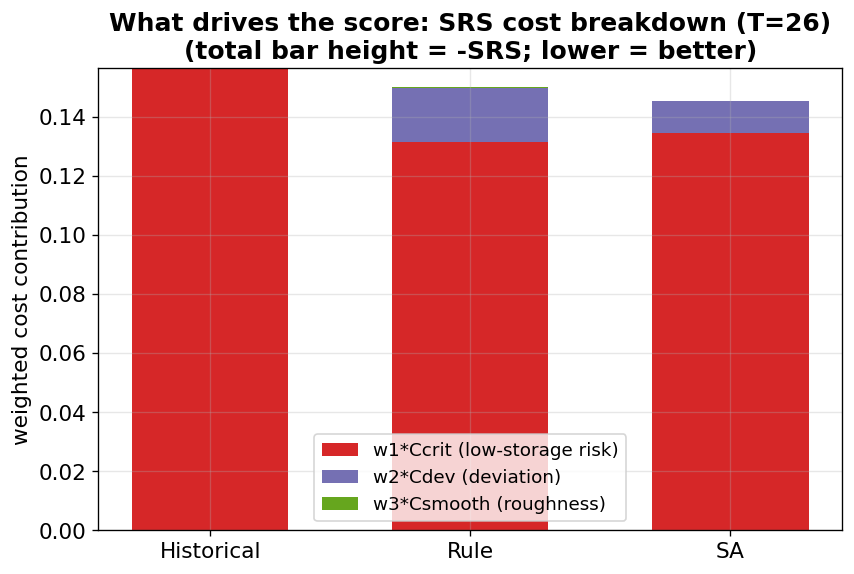

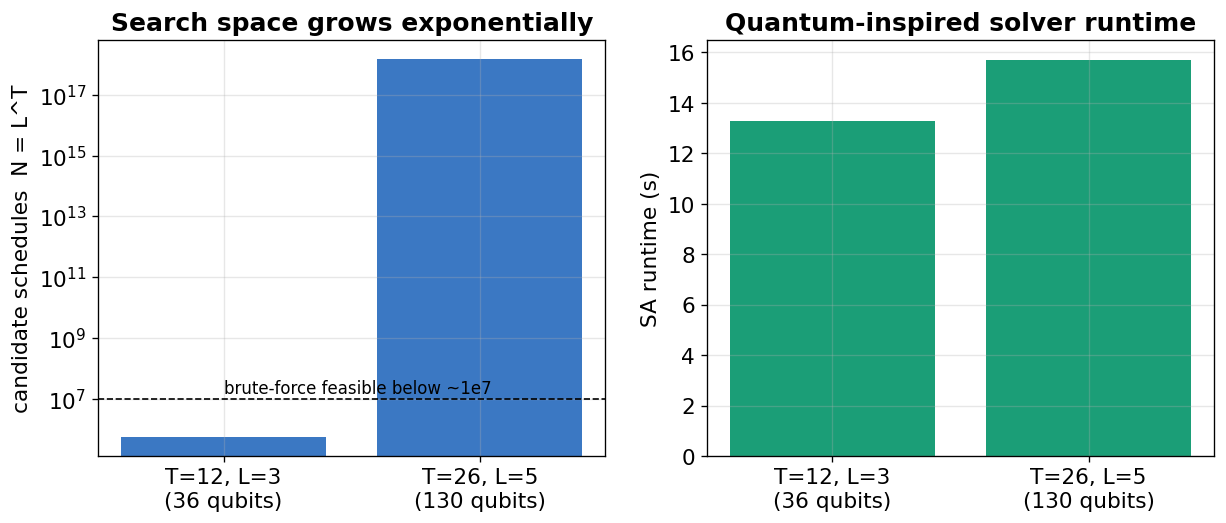

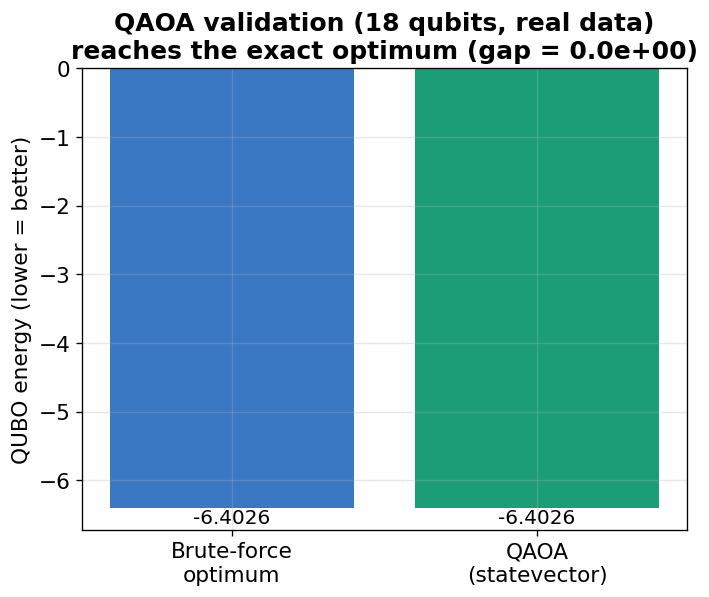

Saved presentation figures:
   figures/fig1_storage_trajectory.png
   figures/fig2_delta_srs_headline.png
   figures/fig3_cost_breakdown.png
   figures/fig4_scaling.png
   figures/fig5_qaoa_validation.png


In [26]:
# ============================================================
# D  Presentation figures  ->  figures/*.png
# ============================================================
import os
import matplotlib.pyplot as plt

FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 13, "axes.titlesize": 15, "axes.titleweight": "bold",
    "axes.labelsize": 13, "legend.fontsize": 11,
    "axes.grid": True, "grid.alpha": 0.3,
})
COL = {"hist": "#8c8c8c", "rule": "#e08214", "sa": "#1b9e77",
       "bf": "#3b78c3", "smin": "#d62728"}
small, med = results[0], results[1]
saved = []

def _save(fig, name):
    f = os.path.join(FIGDIR, name)
    fig.savefig(f)
    saved.append(f)
    plt.show()

# ---- Fig 1: storage trajectory (official medium) -- hero visual ----
inst = med["inst"]; wk = np.arange(inst["T"] + 1)
Sh = storage_traj(historical_replay(inst), inst)
Ss = storage_traj(med["u_sa"], inst)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(wk, Sh, "o-", color=COL["hist"], lw=2, label="Historical (u=0)")
ax.plot(wk, Ss, "s-", color=COL["sa"], lw=2.5, label="Optimized (SA)")
ax.axhline(inst["Smin"], ls="--", color=COL["smin"], lw=2, label="Smin (critical)")
ax.fill_between(wk, Ss, Sh, where=(Ss >= Sh), color=COL["sa"], alpha=0.12,
                label="storage protected")
ax.set_title("Storage trajectory - Falcon T=26 (official instance)")
ax.set_xlabel("week"); ax.set_ylabel("storage (TCM)"); ax.legend()
_save(fig, "fig1_storage_trajectory.png")

# ---- Fig 2: headline -- improvement in SRS over historical (medium) ----
d_rule = med["srs_rule"] - med["srs_hist"]
d_sa = med["srs_sa"] - med["srs_hist"]
fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.bar(["Threshold rule\n(classical)", "QAOA-inspired\nSA"],
              [d_rule, d_sa], color=[COL["rule"], COL["sa"]])
ax.axhline(0, color="k", lw=1)
for b, v in zip(bars, [d_rule, d_sa]):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.4f}",
            ha="center", va="bottom", fontsize=13, fontweight="bold")
ax.set_title("Improvement in Storage Resilience Score\nover historical operation (T=26, L=5)")
ax.set_ylabel("Delta SRS vs historical  (higher = better)")
_save(fig, "fig2_delta_srs_headline.png")

# ---- Fig 3: SRS cost breakdown by policy (medium) ----
def contrib(u):
    w1, w2, w3 = official_weights(inst); m = score_srs(u, inst)
    return np.array([w1 * m["Ccrit"], w2 * m["Cdev"], w3 * m["Csmooth"]])
pol = {"Historical": historical_replay(inst), "Rule": threshold_rule(inst), "SA": med["u_sa"]}
comp = {k: contrib(v) for k, v in pol.items()}
labels = list(pol.keys()); x = np.arange(len(labels))
c_crit = [comp[k][0] for k in labels]; c_dev = [comp[k][1] for k in labels]
c_smo = [comp[k][2] for k in labels]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x, c_crit, 0.6, label="w1*Ccrit (low-storage risk)", color="#d62728")
ax.bar(x, c_dev, 0.6, bottom=c_crit, label="w2*Cdev (deviation)", color="#7570b3")
ax.bar(x, c_smo, 0.6, bottom=np.array(c_crit) + np.array(c_dev),
       label="w3*Csmooth (roughness)", color="#66a61e")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title("What drives the score: SRS cost breakdown (T=26)\n(total bar height = -SRS; lower = better)")
ax.set_ylabel("weighted cost contribution"); ax.legend()
_save(fig, "fig3_cost_breakdown.png")

# ---- Fig 4: scaling -- search space & runtime ----
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
labs = [f"T={r['T']}, L={r['L']}\n({r['qubits']} qubits)" for r in results]
Ns = [float(r["N"]) for r in results]
ax[0].bar(labs, Ns, color=COL["bf"])
ax[0].set_yscale("log"); ax[0].set_ylabel("candidate schedules  N = L^T")
ax[0].axhline(1e7, ls="--", color="k", lw=1)
ax[0].text(0, 1.5e7, "brute-force feasible below ~1e7", fontsize=10)
ax[0].set_title("Search space grows exponentially")
ax[1].bar(labs, [r["sa_time"] for r in results], color=COL["sa"])
ax[1].set_ylabel("SA runtime (s)"); ax[1].set_title("Quantum-inspired solver runtime")
_save(fig, "fig4_scaling.png")

# ---- Fig 5: QAOA validation on the 18-qubit real slice ----
fig, ax = plt.subplots(figsize=(6.5, 5))
bars = ax.bar(["Brute-force\noptimum", "QAOA\n(statevector)"],
              [e_min, qres.fval], color=[COL["bf"], COL["sa"]])
for b, v in zip(bars, [e_min, qres.fval]):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.4f}", ha="center",
            va="bottom" if v >= 0 else "top", fontsize=12)
gap = abs(qres.fval - e_min)
ax.set_title(f"QAOA validation ({meta_v['n']} qubits, real data)\n"
             f"reaches the exact optimum (gap = {gap:.1e})")
ax.set_ylabel("QUBO energy (lower = better)")
_save(fig, "fig5_qaoa_validation.png")

print("Saved presentation figures:")
for f in saved:
    print("  ", f)


## Appendix — Troubleshooting

### The QAOA cell hangs / produces no output

This almost always means Aer failed to import and it fell back to the slow
pure-Python reference sampler. Check the §2 output:

* `Using sampler: Aer SamplerV2 (GPU)` -> good, GPU path.
* `Using sampler: StatevectorSampler (reference, pure Python)` -> Aer is broken.

With the current notebook, `solve_with_qaoa` auto-switches to a fast NumPy
statevector QAOA in that case, so §11 still completes in seconds. You can
force it either way with `method="qiskit"` or `method="statevector"`.

### `ImportError: cannot import name 'convert_to_target' from 'qiskit.providers'`

The installed `qiskit-aer` is older than `qiskit`. Fix, in order:

1. Run §1 (it installs with `sys.executable -m pip`, i.e. the kernel's own
   interpreter -- a bare `!pip` may target a different environment).
2. **Restart the kernel** and run from the top. Python caches the broken
   `qiskit_aer` on first import, so a restart is mandatory.
3. If the base venv is locked (e.g. read-only `/opt/qcentroid-venv`) and the
   install still doesn't take, just use the NumPy statevector path -- it needs
   no Aer at all.

### GPU vs CPU speed

For 18 qubits, GPU/CPU/statevector all finish quickly. GPU only helps for
larger circuits. Use the brute-force cell (§10) to validate the QUBO first.